# Laptop Price Prediction Analysis

<img src="assets/images/laptop_pic.jpg" alt="Laptop Price Prediction Project" width="900"/>

This report combines data cleaning, exploratory analysis, and regression modeling to predict laptop prices from technical specifications such as RAM, storage, processor details, display resolution, and build characteristics.

## Research Questions & Objectives

**Research Questions**
1. Which laptop specifications (RAM, CPU family, storage, screen resolution, GPU, etc.) have the strongest relationship with price?
2. Can a Multiple Linear Regression model provide reliable price estimates from available features?
3. How well does the model generalize to unseen laptop records?

**Project Objectives**
- Prepare and validate the dataset for modeling.
- Explore key feature-price patterns using visualizations.
- Train and evaluate a regression model using standard error metrics.

**Hypothesis Testing**
- **Null Hypothesis (H0):** Laptop specifications do not significantly explain variations in laptop price.
- **Alternative Hypothesis (H1):** Laptop specifications significantly explain variations in laptop price.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Preprocessing & EDA

In [ ]:
# Load dataset (use model-ready dataset)
df = pd.read_csv("data/processed/model_laptop_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1303, 18)


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips,Touchscreen,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False,1,0,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False,1,0,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False,1,0,2560,1600


In [3]:
# Basic data wrangling checks
print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nData types:")
display(df.dtypes)

# Optional light cleaning
before = df.shape[0]
df = df.drop_duplicates().copy()
after = df.shape[0]
print(f"\nRemoved duplicates: {before - after}")


Missing values by column:


Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
Processor_Brand     0
Processor_Family    0
Is_Gaming_Laptop    0
Ips                 0
Touchscreen         0
X_res               0
Y_res               0
dtype: int64


Data types:


Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight              float64
Price               float64
Processor_Brand      object
Processor_Family     object
Is_Gaming_Laptop       bool
Ips                   int64
Touchscreen           int64
X_res                 int64
Y_res                 int64
dtype: object


Removed duplicates: 29


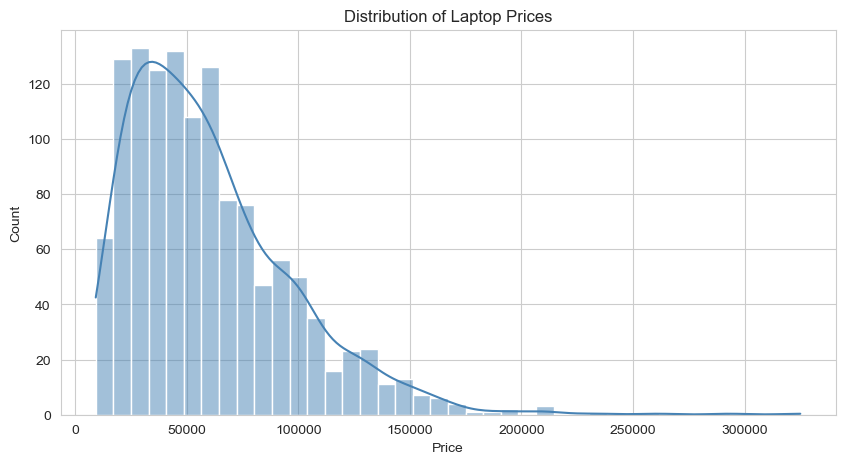

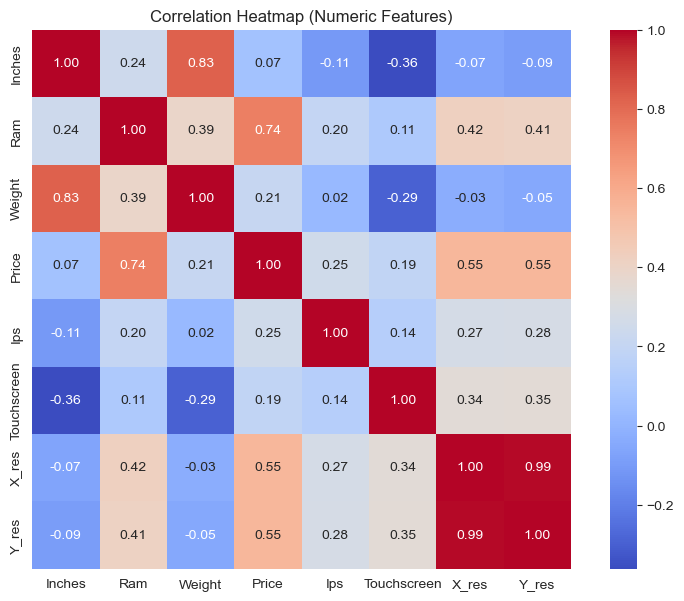

In [4]:
# EDA 1: Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# EDA 2: Correlation heatmap (numeric features)
numeric_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

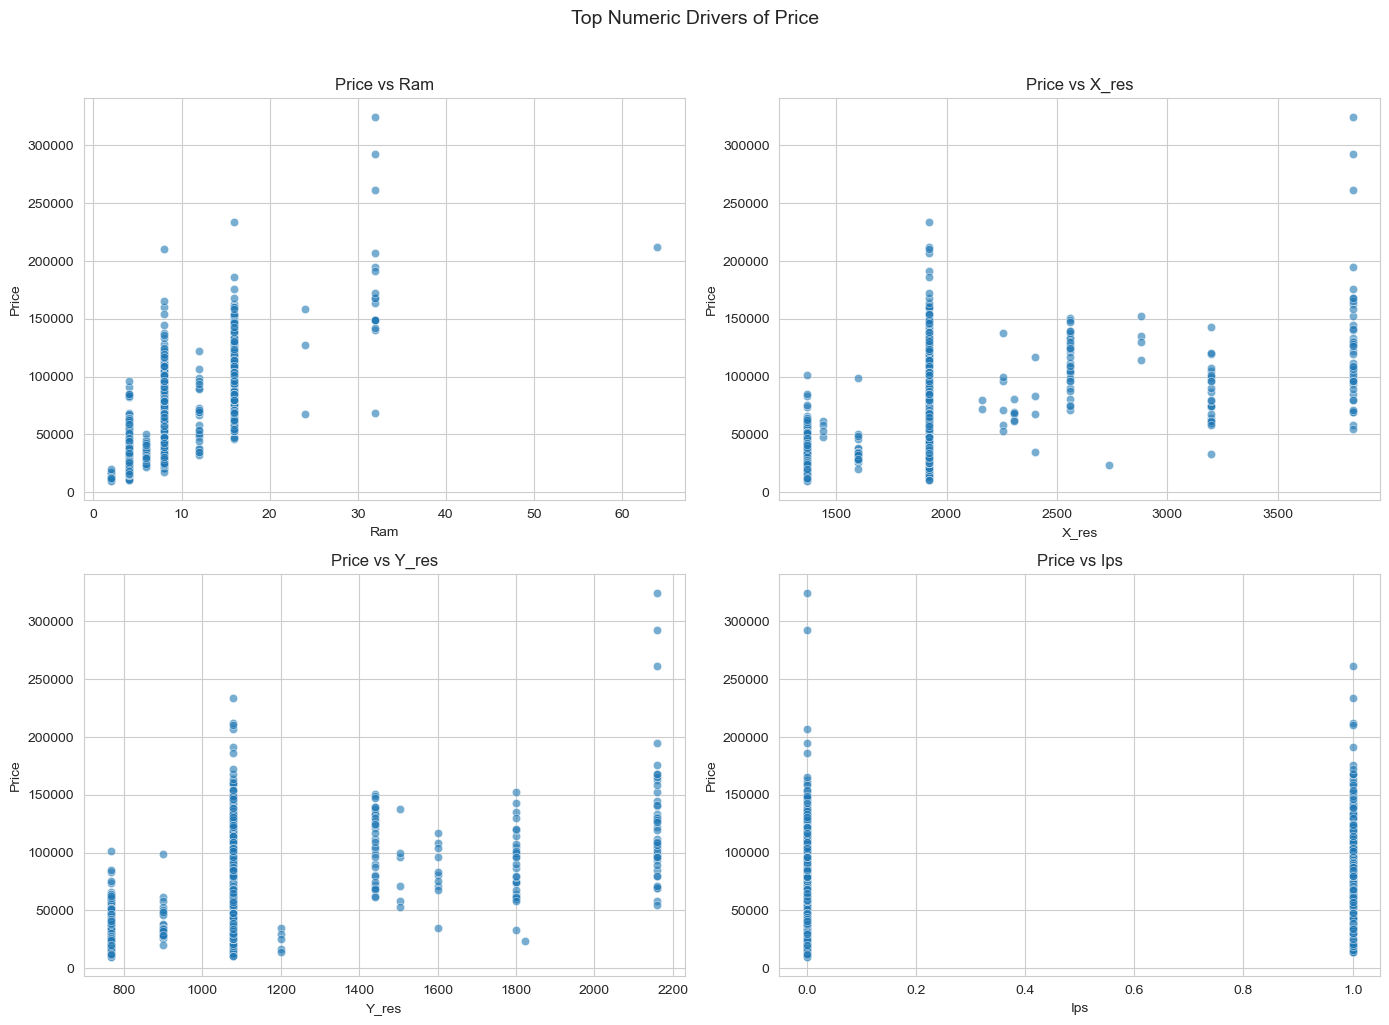

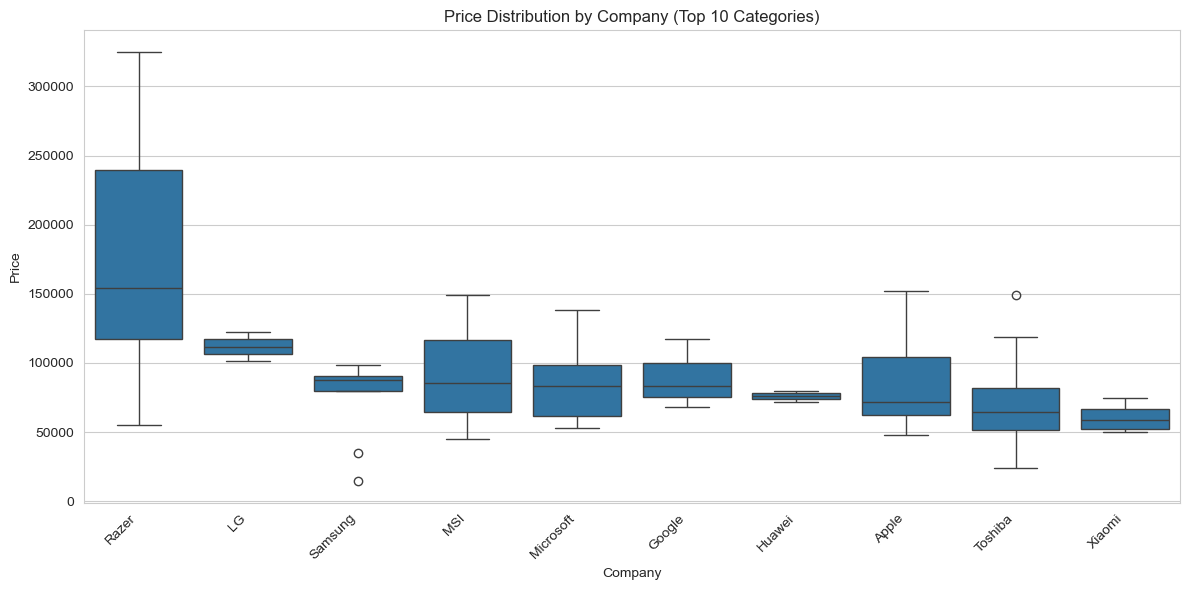

In [5]:
# EDA 3: Additional feature-price visuals
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
if "Price" in numeric_cols:
    corr_to_price = (
        df[numeric_cols]
        .corr()["Price"]
        .drop("Price")
        .abs()
        .sort_values(ascending=False)
    )
    top_numeric_features = corr_to_price.head(4).index.tolist()

    if top_numeric_features:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        for i, feature in enumerate(top_numeric_features):
            sns.scatterplot(data=df, x=feature, y="Price", alpha=0.6, ax=axes[i])
            axes[i].set_title(f"Price vs {feature}")

        for j in range(len(top_numeric_features), 4):
            fig.delaxes(axes[j])

        plt.suptitle("Top Numeric Drivers of Price", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()

# Categorical feature visualization (if categorical columns exist)
cat_cols = [col for col in df.columns if df[col].dtype == "object" and col != "Price"]
if cat_cols:
    top_cat = cat_cols[0]
    plt.figure(figsize=(12, 6))
    order = (
        df.groupby(top_cat)["Price"]
        .median()
        .sort_values(ascending=False)
        .head(10)
        .index
    )
    sns.boxplot(data=df[df[top_cat].isin(order)], x=top_cat, y="Price", order=order)
    plt.title(f"Price Distribution by {top_cat} (Top 10 Categories)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### EDA Interpretation
- The scatter plots highlight which numeric specifications move most strongly with price.
- The category boxplot shows whether certain brands/types create clear median price separation.
- Strong monotonic trends support linear modeling assumptions; heavy dispersion indicates room for nonlinear improvements.

In [6]:
# Train/Test Split
target = "Price"
X = df.drop(columns=[target])
y = df[target]

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1019, 352)
X_test shape: (255, 352)
y_train shape: (1019,)
y_test shape: (255,)


## Model Implementation

### Model Choice Reasoning
Multiple Linear Regression is selected as a baseline because the target variable (price) is continuous, and we want interpretable relationships between laptop specifications and predicted price. It also provides a strong reference point before trying more complex models.

### Model Training Diagram

Raw Data
   |
   v
Preprocessing + Encoding
   |
   v
Train/Test Split
   |
   v
Feature Scaling
   |
   v
Multiple Linear Regression Training
   |
   v
Predictions + Evaluation

In [7]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify feature shapes
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("Model training completed.")

Scaled X_train shape: (1019, 352)
Scaled X_test shape: (255, 352)
Model training completed.


## Results & Conclusions

MSE  : 316649260.38
RMSE : 17794.64
R^2  : 0.8152


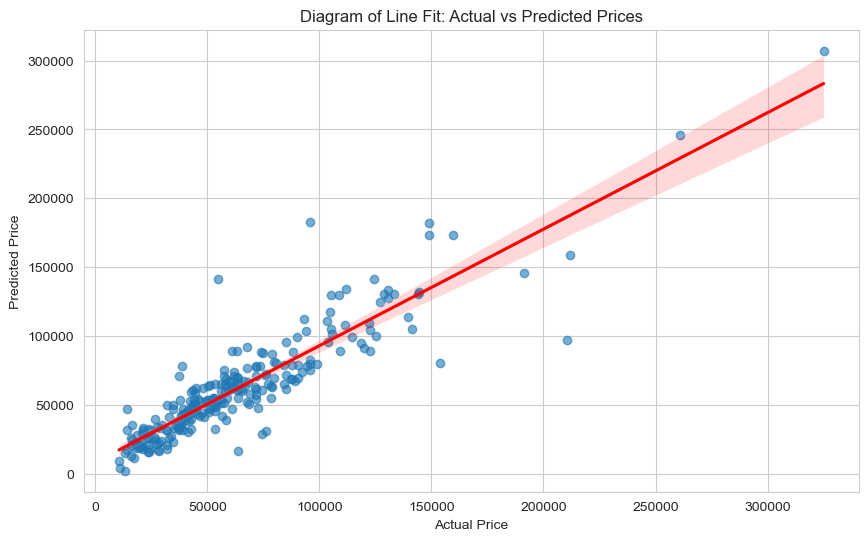

In [8]:
# Predictions and error metrics
y_pred = lr_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")

# Diagram of Line Fit: Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Diagram of Line Fit: Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

MAE  : 11231.90
MSE  : 316649260.38
RMSE : 17794.64
R^2  : 0.8152


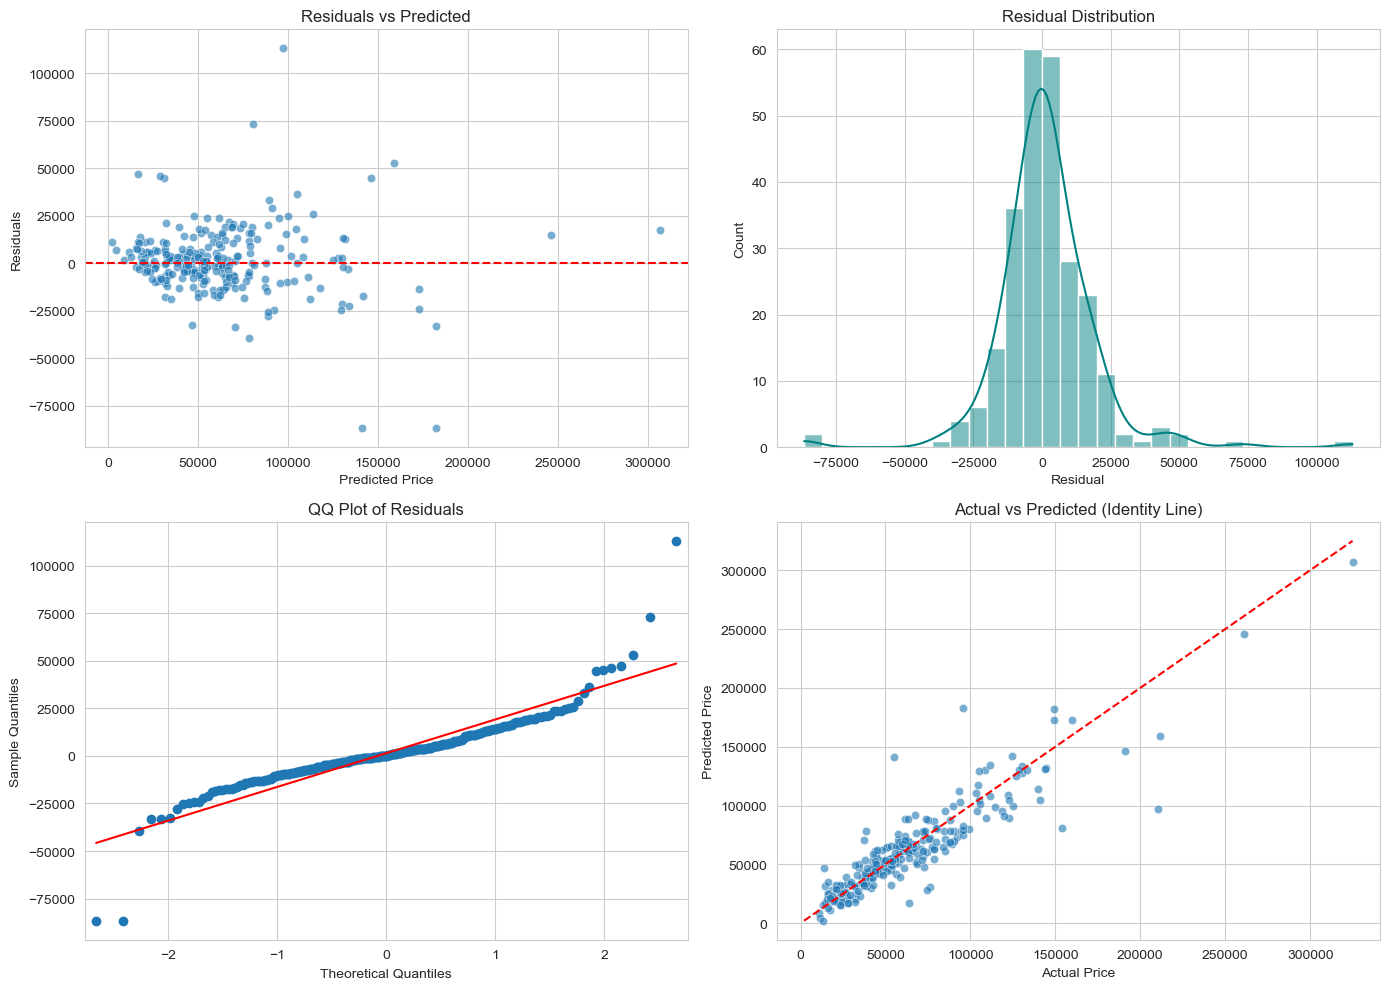

In [9]:
# Extended model evaluation metrics
y_pred = lr_model.predict(X_test_scaled)
residuals = y_test - y_pred

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")

# Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=axes[0, 0])
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals vs Predicted")
axes[0, 0].set_xlabel("Predicted Price")
axes[0, 0].set_ylabel("Residuals")

# 2) Residual distribution
sns.histplot(residuals, kde=True, bins=30, color="teal", ax=axes[0, 1])
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("Residual")

# 3) QQ plot of residuals
qqplot(residuals, line="s", ax=axes[1, 0])
axes[1, 0].set_title("QQ Plot of Residuals")

# 4) Actual vs Predicted with identity line
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, ax=axes[1, 1])
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], "r--")
axes[1, 1].set_title("Actual vs Predicted (Identity Line)")
axes[1, 1].set_xlabel("Actual Price")
axes[1, 1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

In [10]:
# OLS regression (inferential model) and test-set evaluation
X_train_ols = sm.add_constant(X_train_scaled, has_constant="add")
X_test_ols = sm.add_constant(X_test_scaled, has_constant="add")

ols_model = sm.OLS(y_train, X_train_ols).fit()
print(ols_model.summary())

ols_test_pred = ols_model.predict(X_test_ols)
ols_mse = mean_squared_error(y_test, ols_test_pred)
ols_rmse = np.sqrt(ols_mse)
ols_r2 = r2_score(y_test, ols_test_pred)

print("\nOLS Test Performance")
print(f"MSE  : {ols_mse:.2f}")
print(f"RMSE : {ols_rmse:.2f}")
print(f"R^2  : {ols_r2:.4f}")

# Top significant OLS coefficients (by p-value)
coef_table = pd.DataFrame({
    "feature": ["const"] + X_train.columns.tolist(),
    "coef": ols_model.params.values,
    "p_value": ols_model.pvalues.values
}).sort_values("p_value")

print("\nTop significant coefficients:")
display(coef_table.head(10))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     28.43
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          1.87e-273
Time:                        21:16:00   Log-Likelihood:                -10894.
No. Observations:                1019   AIC:                         2.234e+04
Df Residuals:                     742   BIC:                         2.371e+04
Df Model:                         276                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.984e+04    390.552    153.218      0.0

,feature,coef,p_value
0,const,59839.532429,0.000000e+00
22,Company_Razer,3783.729905,5.453906e-14
2,Ram,6250.385333,6.599288e-12
351,Processor_Family_Intel Xeon,2483.176098,1.379992e-09
7,X_res,1594.284772,2.156426e-08
8,Y_res,1597.774458,2.193407e-08
70,ScreenResolution_Touchscreen 2560x1440,2449.329375,3.021968e-08
24,Company_Toshiba,2989.661121,1.539816e-06
15,Company_HP,3964.664438,1.361748e-05
61,ScreenResolution_IPS Panel Touchscreen 2560x1440,1809.423259,1.831671e-05


### Model Diagnostic Interpretation
- **Residuals vs Predicted:** A random cloud around 0 suggests linearity and stable error behavior.
- **Residual Histogram + QQ Plot:** If residuals are roughly bell-shaped and points follow the QQ line, normality is reasonably satisfied.
- **Actual vs Predicted:** Points close to the diagonal indicate strong predictive alignment.
- **OLS p-values:** Features with low p-values provide statistically significant evidence of contribution to price prediction, supporting rejection of the null hypothesis.
- **Practical takeaway:** RMSE gives the typical prediction error in price units and is the most intuitive metric for business interpretation.

### Statistical Summary
- **MSE / RMSE / MAE** quantify prediction error magnitude; lower values indicate better fit.
- **R-squared** captures variance explained by the model; higher values indicate stronger explanatory power.
- **OLS summary output** provides coefficient significance tests, confidence intervals, and global fit diagnostics.
- If most key predictors are statistically significant and test-set R-squared remains strong, the model demonstrates both interpretability and generalization.

### Conclusion
Based on the regression performance metrics (especially a meaningful R-squared with reasonable RMSE), we **reject the Null Hypothesis (H0)** and accept that laptop specifications significantly contribute to predicting laptop prices.